In [2]:
#importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
#load dataset
df = pd.read_csv("Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
#finding outliers in the dataset
df.describe()


,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
#separating data based on country
df_spain = df[df['country'] == 'Spain']
df_germany = df[df['country'] == 'Germany']
df_france = df[df['country'] == 'France']


In [ ]:
#demographic distribution in Spain
df_spain['age'].hist(bins=20)
plt.title("Age Distribution in Spain")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()


#gender distribution in spain
df_spain['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution in Spain")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()


#balace distribution in spain
df_spain['balance'].hist(bins=30)
plt.title("Balance Distribution in Spain")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")
plt.show()

#credit score distribution in spain
df_spain['credit_score'].hist(bins=20)
plt.title("Credit Score Distribution in Spain")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#age distribution in germany
df_germany['age'].hist(bins=20)
plt.title("Age Distribution in Germany")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

#gender distribution in germany
df_germany['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution in Germany")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

#balance distribution in germany
df_germany['balance'].hist(bins=30)
plt.title("Balance Distribution in Germany")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")
plt.show()

#credit score distribution in germany
df_germany['credit_score'].hist(bins=20)
plt.title("Credit Score Distribution in Germany")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#age didtribution in france
df_france['age'].hist(bins=20)
plt.title("Age Distribution in France")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

#gender distribution in france
df_france['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution in France")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

#balance distribution in france
df_france['balance'].hist(bins=30)
plt.title("Balance Distribution in France")
plt.xlabel("Balance")
plt.ylabel("Number of Customers")
plt.show()

#credit score distibution in france
df_france['credit_score'].hist(bins=20)
plt.title("Credit Score Distribution in France")
plt.xlabel('credit score')
plt.ylabel("Number of Customers")
plt.show()

In [26]:
#churn rate by country
print("Spain ", df_spain['churn'].value_counts(normalize=True))
print(f"Germany  {df_germany['churn'].value_counts(normalize=True)}")
print("France ", df_france['churn'].value_counts(normalize=True))

Spain  churn
0    0.833266
1    0.166734
Name: proportion, dtype: float64
Germany  churn
0    0.675568
1    0.324432
Name: proportion, dtype: float64
France  churn
0    0.838452
1    0.161548
Name: proportion, dtype: float64


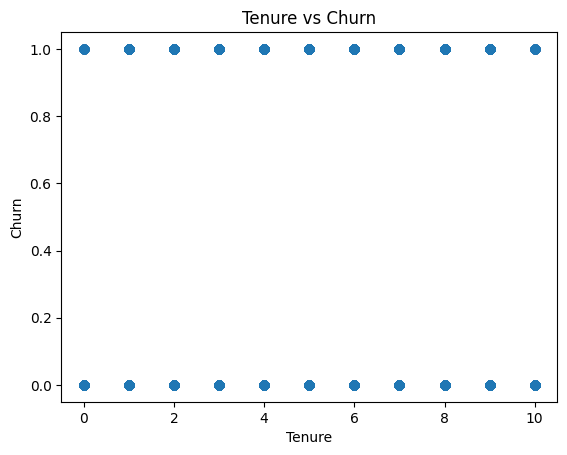

In [ ]:
#global dataset

#relatiionship between tenure and churn
plt.scatter(df['tenure'], df['churn'])
plt.title("Tenure vs Churn")
plt.xlabel("Tenure")
plt.ylabel("Churn")
plt.show()

In [ ]:
#impact of balance and credit score on churn in spain
plt.scatter(df['balance'], df['credit_score'], c=df_spain['churn'], cmap='bwr', alpha=0.7)
plt.title("Balance and Credit Score vs Churn")
plt.xlabel("Balance")
plt.ylabel("Credit Score")
plt.show()

In [ ]:
#correlation heatmap of Global dataset (numeric columns only)
import seaborn as sns
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#churn vs no-churn distribution
df['churn'].value_counts().plot(kind='bar')
plt.title("Churn vs No Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#modeling and prediction
#preparing data for modeling
features = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
